PINC = 91912300
CFG_VAL_RUN = 0x0AF4F0D9
fs_out = 50000 sps
Muestras/símbolo a 9600 bps: 5.21
Conectado.
  ACK: 0x01
  ACK: 0x01
Reseteando FIFO...
  ACK: 0x01
  ACK: 0x01
Pidiendo 4096 muestras complejas (32768 bytes)...
  1464/32768 bytes
  2924/32768 bytes
  4384/32768 bytes
  5844/32768 bytes
  7488/32768 bytes
  10408/32768 bytes
  11868/32768 bytes
  16836/32768 bytes
  19756/32768 bytes
  23600/32768 bytes
  26520/32768 bytes
  30904/32768 bytes
  32364/32768 bytes
  32768/32768 bytes


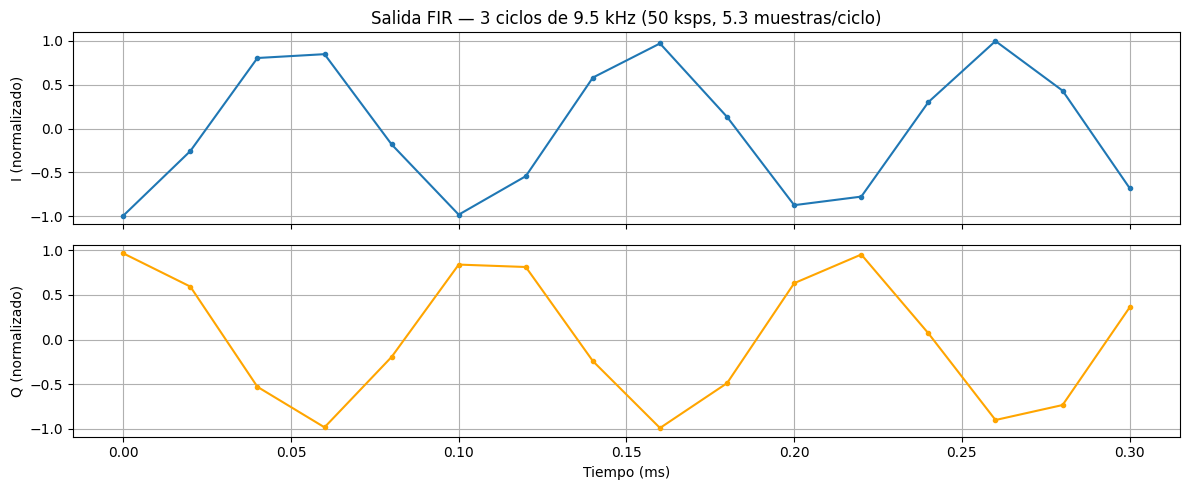

Pico en: -9.50 kHz (esperado: 9.5 kHz)


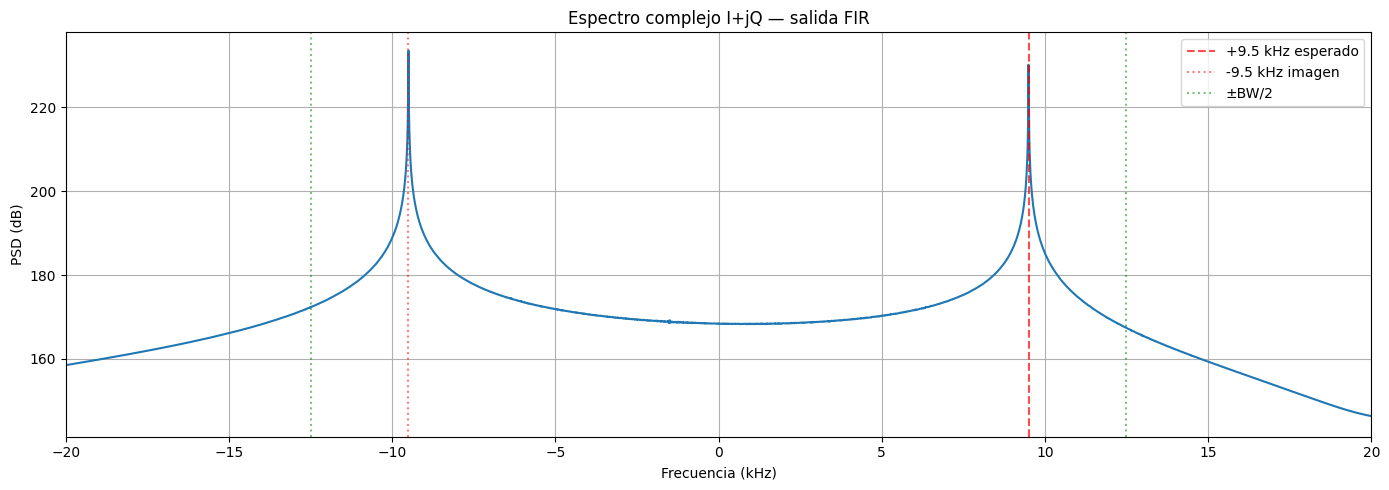

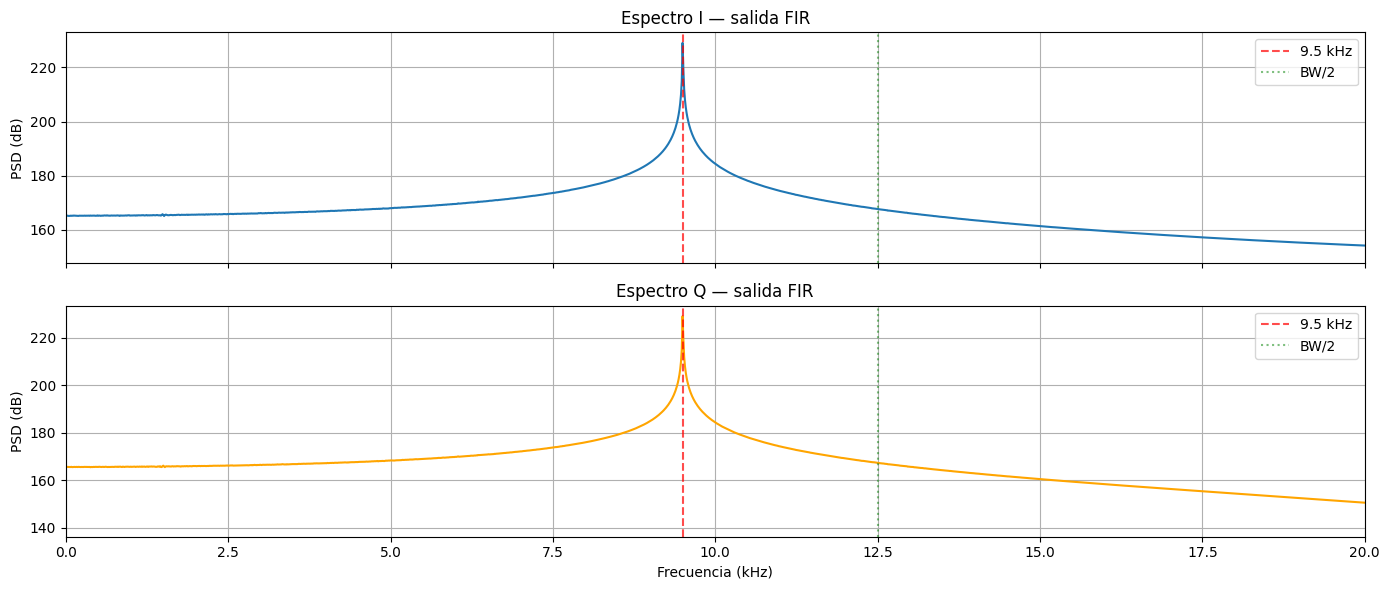

Listo.


In [1]:
import socket
import struct
import numpy as np
import matplotlib.pyplot as plt

HOST = '10.240.46.50'
PORT = 1003

CMD_READ_ADC = 0x03
CMD_SET_FIFO = 0x04
CMD_SET_CFG  = 0x05

fs_out   = 50000.0
f_lo_hz  = 10.7e6
f_offset = 9.5e3

# Rango de visualización espectro
f_min_khz = -20.0
f_max_khz =  20.0

PINC = round(f_lo_hz / 125e6 * (1 << 30))
CFG_VAL_RESET = (PINC << 1) | 0
CFG_VAL_RUN   = (PINC << 1) | 1

print(f"PINC = {PINC}")
print(f"CFG_VAL_RUN = 0x{CFG_VAL_RUN:08X}")
print(f"fs_out = {fs_out:.0f} sps")
print(f"Muestras/símbolo a 9600 bps: {fs_out/9600:.2f}")

def send_cmd(sock, cmd, payload):
    sock.sendall(struct.pack('B', cmd))
    sock.sendall(struct.pack('I', payload))

def read_ack(sock):
    data = sock.recv(1)
    print(f"  ACK: 0x{data[0]:02X}")
    return data[0] == 0x01

def read_adc(sock, n_samples):
    """
    FIR con Number_Channels=2 entrega I y Q alternados, cada uno 32 bits.
    n_samples muestras complejas = n_samples*2 palabras de 32 bits.
    El servidor cuenta palabras de 32 bits → pedimos n_samples*2.
    El FIFO tiene 4096 palabras de 64 bits = 4096 pares I/Q → max n_samples=4096.
    """
    n_words = n_samples * 2

    print("Reseteando FIFO...")
    send_cmd(sock, CMD_SET_FIFO, 0)
    read_ack(sock)
    send_cmd(sock, CMD_SET_FIFO, 1)
    read_ack(sock)

    print(f"Pidiendo {n_samples} muestras complejas ({n_words*4} bytes)...")
    send_cmd(sock, CMD_READ_ADC, n_words)

    raw = b''
    total = n_words * 4
    while len(raw) < total:
        chunk = sock.recv(total - len(raw))
        raw += chunk
        print(f"  {len(raw)}/{total} bytes")

    # int32 con signo — salida del FIR de 32 bits
    words = struct.unpack(f'{n_words}i', raw)
    I_bb = np.array(words[0::2], dtype=float)  # palabras pares = I
    Q_bb = np.array(words[1::2], dtype=float)  # palabras impares = Q
    return I_bb, Q_bb

sock = socket.socket(socket.AF_INET, socket.SOCK_STREAM)
sock.connect((HOST, PORT))
print("Conectado.")

send_cmd(sock, CMD_SET_CFG, CFG_VAL_RESET)
read_ack(sock)
send_cmd(sock, CMD_SET_CFG, CFG_VAL_RUN)
read_ack(sock)

n_samples = 4096
I_bb, Q_bb = read_adc(sock, n_samples)
sock.close()

t = np.arange(n_samples) / fs_out * 1e3  # ms

# Dominio temporal — 3 ciclos
n_ciclos = 3
t_max = n_ciclos / f_offset * 1e3
mask_t = t < t_max
muestras_por_ciclo = fs_out / f_offset

I_norm = I_bb / (np.max(np.abs(I_bb)) + 1e-10)
Q_norm = Q_bb / (np.max(np.abs(Q_bb)) + 1e-10)

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 5), sharex=True)
ax1.plot(t[mask_t], I_norm[mask_t], 'o-', markersize=3)
ax1.set_ylabel('I (normalizado)')
ax1.set_title(f'Salida FIR — {n_ciclos} ciclos de {f_offset/1e3:.1f} kHz '
              f'({fs_out/1e3:.0f} ksps, {muestras_por_ciclo:.1f} muestras/ciclo)')
ax1.grid(True)

ax2.plot(t[mask_t], Q_norm[mask_t], 'o-', markersize=3, color='orange')
ax2.set_ylabel('Q (normalizado)')
ax2.set_xlabel('Tiempo (ms)')
ax2.grid(True)
plt.tight_layout()
plt.show()

# Espectro complejo bilateral con ventana Blackman
S     = np.fft.fftshift(np.fft.fft((I_bb + 1j * Q_bb)))
freqs = np.fft.fftshift(np.fft.fftfreq(n_samples, d=1/fs_out))
Pxx   = 10 * np.log10(np.abs(S)**2 + 1e-20)

freq_peak = freqs[np.argmax(Pxx)]
print(f"Pico en: {freq_peak/1e3:.2f} kHz (esperado: {f_offset/1e3:.1f} kHz)")

fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(freqs/1e3, Pxx)
ax.axvline( f_offset/1e3, color='r', linestyle='--', alpha=0.7,
            label=f'+{f_offset/1e3:.1f} kHz esperado')
ax.axvline(-f_offset/1e3, color='r', linestyle=':', alpha=0.5,
            label=f'-{f_offset/1e3:.1f} kHz imagen')
ax.axvline( 12.5, color='g', linestyle=':', alpha=0.5, label='±BW/2')
ax.axvline(-12.5, color='g', linestyle=':', alpha=0.5)
ax.set_xlabel('Frecuencia (kHz)')
ax.set_ylabel('PSD (dB)')
ax.set_title('Espectro complejo I+jQ — salida FIR')
ax.set_xlim(f_min_khz, f_max_khz)
ax.legend(); ax.grid(True)
plt.tight_layout()
plt.show()

# Espectro I y Q por separado
Pxx_I   = 10 * np.log10(np.abs(np.fft.rfft(I_bb))**2 + 1e-20)
Pxx_Q   = 10 * np.log10(np.abs(np.fft.rfft(Q_bb))**2 + 1e-20)
freqs_r = np.fft.rfftfreq(n_samples, d=1/fs_out)

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 6), sharex=True)
ax1.plot(freqs_r/1e3, Pxx_I)
ax1.axvline(f_offset/1e3, color='r', linestyle='--', alpha=0.7,
            label=f'{f_offset/1e3:.1f} kHz')
ax1.axvline(12.5, color='g', linestyle=':', alpha=0.5, label='BW/2')
ax1.set_ylabel('PSD (dB)'); ax1.set_title('Espectro I — salida FIR')
ax1.set_xlim(0, f_max_khz); ax1.legend(); ax1.grid(True)

ax2.plot(freqs_r/1e3, Pxx_Q, color='orange')
ax2.axvline(f_offset/1e3, color='r', linestyle='--', alpha=0.7,
            label=f'{f_offset/1e3:.1f} kHz')
ax2.axvline(12.5, color='g', linestyle=':', alpha=0.5, label='BW/2')
ax2.set_ylabel('PSD (dB)'); ax2.set_xlabel('Frecuencia (kHz)')
ax2.set_title('Espectro Q — salida FIR')
ax2.set_xlim(0, f_max_khz); ax2.legend(); ax2.grid(True)
plt.tight_layout()
plt.show()

print("Listo.")